In [2]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pywt
from skimage.transform import resize
import tensorflow.keras.backend as K
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [3]:

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
# X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)



In [4]:
# def generate_scalogram(segment, image_shape, fs=48000, scales=np.geomspace(1, 128), wavelet='cmor', log_scale=True, debug=False, label_name=None):
#     coeffs, freqs = pywt.cwt(segment, scales, wavelet, sampling_period=1/fs)
#     scalogram = np.log1p(np.abs(coeffs))
#     # scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))  # Normalize
#     scalogram -= scalogram.min()
#     scalogram /= scalogram.max()
#     scalogram = resize(scalogram, image_shape, mode='constant', anti_aliasing=True)
#     return scalogram

def generate_scalogram(segment, image_shape, fs=48000, scales=np.arange(1, 128), wavelet='morl'):
    coeffs, freqs = pywt.cwt(segment, scales, wavelet, sampling_period=1/fs)
    scalogram = np.abs(coeffs)
    scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))  # Normalize
    scalogram = resize(scalogram, image_shape, mode='constant', anti_aliasing=True)
    return scalogram

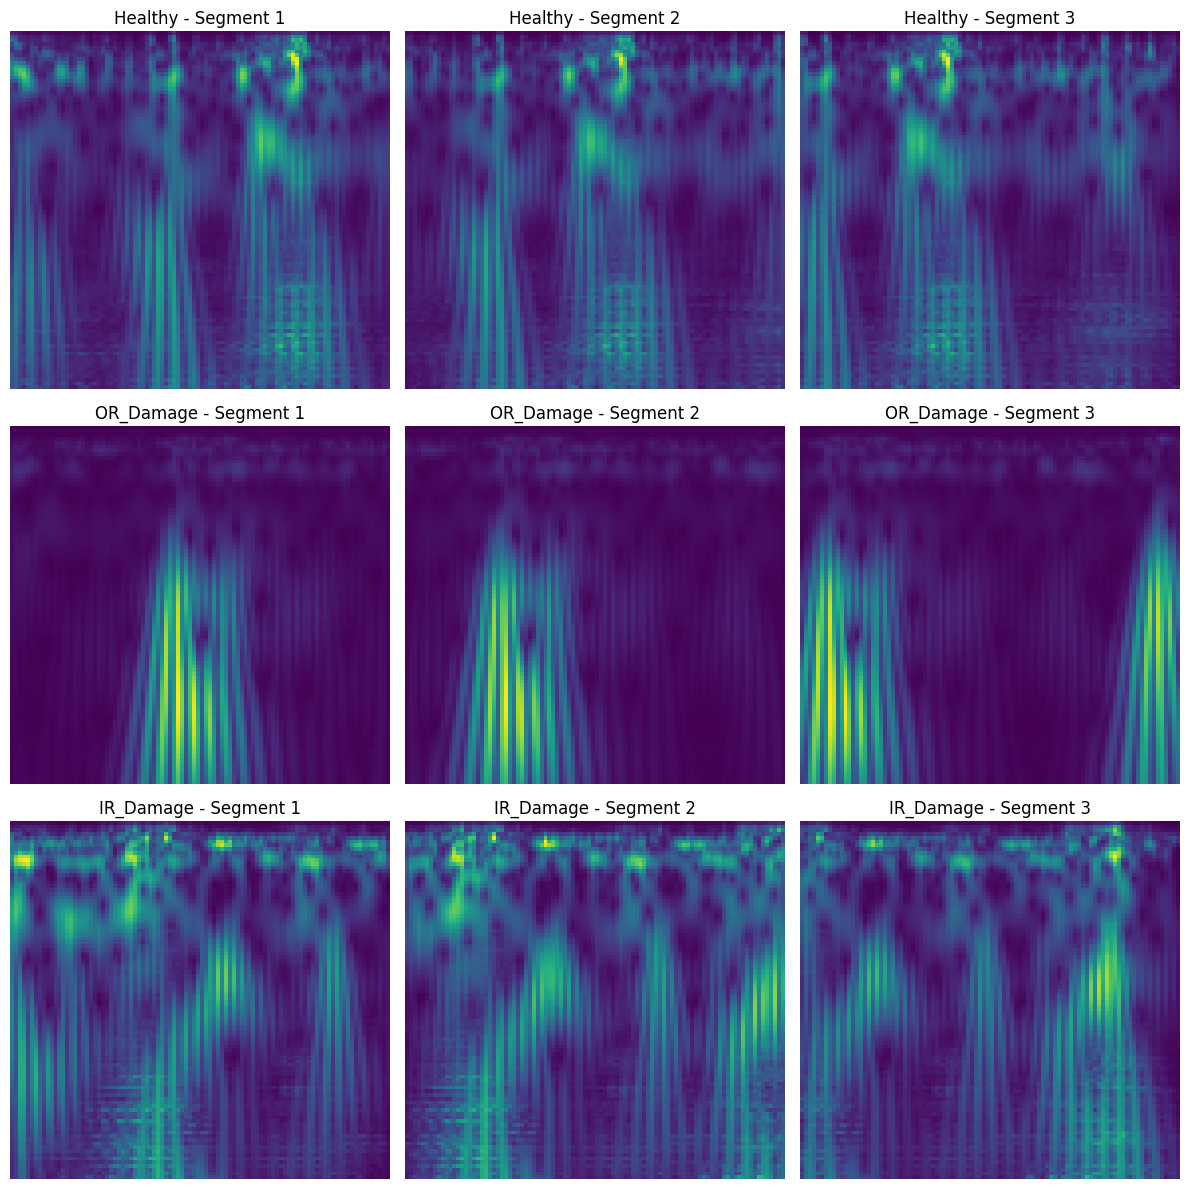

In [5]:

def plot_scalogram_grid(scalograms, titles, n_cols=3):
    n_rows = int(np.ceil(len(scalograms) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for idx, (scalogram, title) in enumerate(zip(scalograms, titles)):
        axes[idx].imshow(scalogram, aspect='auto', cmap='viridis')
        axes[idx].set_title(title)
        axes[idx].axis('off')
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Parameters
image_shape = (96, 96)
samples_per_block = 1600
interval_length = 290
num_samples_per_class = 3

# Sampling function
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

# Generate scalograms for each class
scalograms_to_plot = []
titles = []
for class_idx, signal_array in enumerate(grouped_signals[:3]):  # Only classes 0 to 2
    class_name = data_structure[class_idx][0]
    sampled_segments = Sampling(signal_array, interval_length, samples_per_block)
    for i in range(min(num_samples_per_class, len(sampled_segments))):
        scalogram = generate_scalogram(sampled_segments[i], image_shape=image_shape)
        scalograms_to_plot.append(scalogram)
        titles.append(f"{class_name} - Segment {i+1}")

# Plot
plot_scalogram_grid(scalograms_to_plot, titles)

In [6]:

# Updated per-file DataPreparation with time-based split
def process_each_mat_file_separately(data_structure, root_dir, interval_length, samples_per_block, train_ratio, sample_limit_per_label,image_shape):
    all_train_segments, all_test_segments = [], []
    all_train_labels_positional, all_test_labels_positional = [], []
    all_train_labels, all_test_labels = [], []
    segment_counts = {0: 0, 1: 0, 2: 0}
   
    
    for label, (label_name, folders) in data_structure.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                continue
            mat_path = os.path.join(folder_path, mat_files[0])
            df = extract_signals_df(mat_path)
            df = df.iloc[:sample_limit_per_label[label]].copy()
            signal = df["vibration"].values.flatten()

            # Sampling
            segments = Sampling(signal, interval_length, samples_per_block)

            scalograms = np.array([generate_scalogram(seg, image_shape, fs=48000) for seg in segments])
            
            segment_counts[label] += segments.shape[0]
            if segments.shape[0] == 0:
                continue
            n_segments = segments.shape[0]
            split_idx = int(n_segments * train_ratio)

            train_segments = scalograms[:split_idx]
            test_segments = scalograms[split_idx:]

            y_train_pos = np.zeros((train_segments.shape[0], len(data_structure)))
            y_train_pos[:, label] = 1
            y_train = np.full((train_segments.shape[0], 1), label)

            y_test_pos = np.zeros((test_segments.shape[0], len(data_structure)))
            y_test_pos[:, label] = 1
            y_test = np.full((test_segments.shape[0], 1), label)

            all_train_segments.append(train_segments)
            all_test_segments.append(test_segments)
            all_train_labels_positional.append(y_train_pos)
            all_test_labels_positional.append(y_test_pos)
            all_train_labels.append(y_train)
            all_test_labels.append(y_test)

    print("\nSegmented dataset shape:")
    for label in sorted(segment_counts.keys()):
        fault_label = data_structure[label][0]
        print(f"Class: {label} Fault Label: {fault_label} Segments: {segment_counts[label]} segments")
        
    # Final combine
    X_train = np.vstack(all_train_segments).reshape([-1, *image_shape, 1])
    X_test = np.vstack(all_test_segments).reshape([-1, *image_shape, 1])
    Y_train = np.vstack(all_train_labels_positional)
    Y_test = np.vstack(all_test_labels_positional)
    y_train = np.vstack(all_train_labels)
    y_test = np.vstack(all_test_labels)

    return X_train, X_test, Y_train, Y_test, y_train, y_test


In [7]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR
image_shape=(96, 96)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = process_each_mat_file_separately(
    data_structure, root_dir, interval_length, samples_per_block, train_ratio=0.8, sample_limit_per_label=sample_limit_per_label, image_shape=image_shape
)

input_shape = (96, 96, 1)   # Reshaped input for CNN 2D
# print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split
X_2D_test = X_test_split

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Segmented dataset shape:
Class: 0 Fault Label: Healthy Segments: 3970 segments
Class: 1 Fault Label: OR_Damage Segments: 50 segments
Class: 2 Fault Label: IR_Damage Segments: 50 segments

Class distribution in training set:
Class 0: 3175 samples
Class 1: 40 samples
Class 2: 40 samples

Class distribution in test set:
Class 0: 795 samples
Class 1: 10 samples
Class 2: 10 samples
Train label distribution: [3175   40   40]
Test label distribution: [795  10  10]

X_2D_train shape: (3255, 96, 96, 1)
Y_train shape: (3255, 3)
X_2D_test shape: (815, 96, 96, 1)
Y_test shape: (815, 3)


In [8]:
# Flatten the integer labels for compute_class_weight
y_train_flat = y_label_train.flatten()  # Shape: (3326,)

y_train_flat = y_label_train.flatten()  # Shape: (3326,)

# Compute weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)

# Convert to dictionary {class_idx: weight}
class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)

alpha = class_weights_array / np.sum(class_weights_array)  # Normalize to sum to 1 (optional)
print("Computed alpha for focal loss:", alpha)

Class weights: {0: np.float64(0.3417322834645669), 1: np.float64(27.125), 2: np.float64(27.125)}
Computed alpha for focal loss: [0.00625978 0.49687011 0.49687011]


In [9]:
def focal_loss(alpha,gamma):
    alpha = K.constant(alpha, dtype=K.floatx())
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=1)
    return loss
    
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(96, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=focal_loss(alpha=[0.05, 0.475, 0.475], gamma=2.0),
                      metrics=['accuracy'])
        return model

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

 Trainable params: 306,387 (1.17 MB)

 Non-trainable params: 480 (1.88 KB)

Epoch 1/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.1872 - loss: 0.2683
Epoch 1: val_accuracy improved from -inf to 0.97542, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 38s 406ms/step - accuracy: 0.1871 - loss: 0.2676 - val_accuracy: 0.9754 - val_loss: 0.0263
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.2278 - loss: 0.1155
Epoch 2: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 391ms/step - accuracy: 0.2280 - loss: 0.1153 - val_accuracy: 0.9754 - val_loss: 0.0512
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.2864 - loss: 0.0652
Epoch 3: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 340ms/step - accuracy: 0.2868 - loss: 0.0653 - val_accuracy: 0.9754 - val_loss: 0.1230
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.1932 - loss: 0.0368
Epoch 4: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.1943 - loss: 0.0369 - val_accuracy: 0.9754 - val_loss: 0.0935
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.3923 - loss: 0.0300
Epoch 5: val_accuracy did n

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step


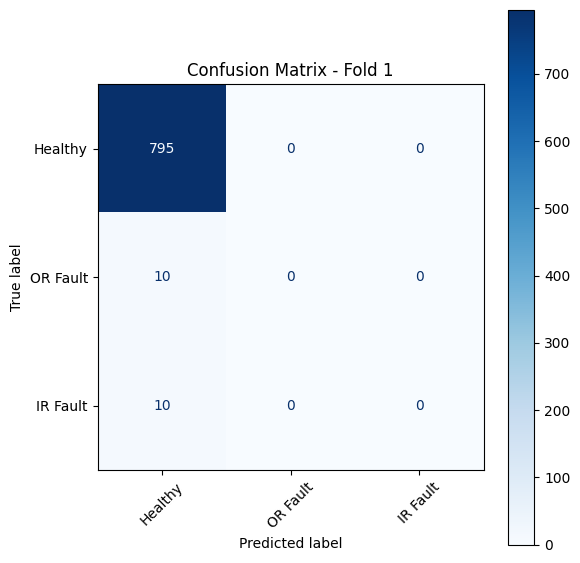

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulari

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

Epoch 1/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.1090 - loss: 0.3130
Epoch 1: val_accuracy improved from -inf to 0.97542, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 38s 432ms/step - accuracy: 0.1087 - loss: 0.3116 - val_accuracy: 0.9754 - val_loss: 0.0235
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.0540 - loss: 0.1132
Epoch 2: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.0540 - loss: 0.1137 - val_accuracy: 0.9754 - val_loss: 0.0305
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.0519 - loss: 0.1216
Epoch 3: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 355ms/step - accuracy: 0.0517 - loss: 0.1219 - val_accuracy: 0.0123 - val_loss: 0.0388
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.0258 - loss: 0.0804
Epoch 4: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 348ms/step - accuracy: 0.0259 - loss: 0.0804 - val_accuracy: 0.9754 - val_loss: 0.0613
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.0407 - loss: 0.0541
Epoch 5: val_accuracy did n

82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 358ms/step - accuracy: 0.1778 - loss: 0.0382 - val_accuracy: 0.9770 - val_loss: 0.0296
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.3678 - loss: 0.0174
Epoch 8: val_accuracy did not improve from 0.97696
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 366ms/step - accuracy: 0.3680 - loss: 0.0174 - val_accuracy: 0.9754 - val_loss: 0.0150
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.5062 - loss: 0.0188
Epoch 9: val_accuracy did not improve from 0.97696
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 369ms/step - accuracy: 0.5056 - loss: 0.0191 - val_accuracy: 0.3303 - val_loss: 0.0391
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.1361 - loss: 0.0589
Epoch 10: val_accuracy did not improve from 0.97696
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 366ms/step - accuracy: 0.1368 - loss: 0.0588 - val_accuracy: 0.4255 - val_loss: 0.0247
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.3253 - loss: 0.0217
Epoch 11: val_accuracy d

82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 361ms/step - accuracy: 0.8783 - loss: 0.0024 - val_accuracy: 0.9816 - val_loss: 0.0041
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9384 - loss: 0.0013
Epoch 30: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 354ms/step - accuracy: 0.9385 - loss: 0.0013 - val_accuracy: 0.9677 - val_loss: 0.0042
Epoch 31/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9434 - loss: 0.0016
Epoch 31: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 359ms/step - accuracy: 0.9433 - loss: 0.0016 - val_accuracy: 0.8694 - val_loss: 0.0083
Epoch 32/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8010 - loss: 0.0070
Epoch 32: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 29s 357ms/step - accuracy: 0.8008 - loss: 0.0069 - val_accuracy: 0.5515 - val_loss: 0.0169
Epoch 33/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8580 - loss: 0.0034
Epoch 33: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 395ms/step - accuracy: 0.9534 - loss: 9.2788e-04 - val_accuracy: 0.9908 - val_loss: 0.0052
Epoch 38/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6015 - loss: 0.1663
Epoch 38: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 388ms/step - accuracy: 0.5989 - loss: 0.1666 - val_accuracy: 0.0184 - val_loss: 0.7036
Epoch 39/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.1753 - loss: 0.0898
Epoch 39: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 411ms/step - accuracy: 0.1756 - loss: 0.0896 - val_accuracy: 0.0215 - val_loss: 0.2383
Epoch 40/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.2582 - loss: 0.0504
Epoch 40: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.2586 - loss: 0.0503 - val_accuracy: 0.4823 - val_loss: 0.0194
Epoch 41/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.4490 - loss: 0.0229
Epoch 41: val_ac

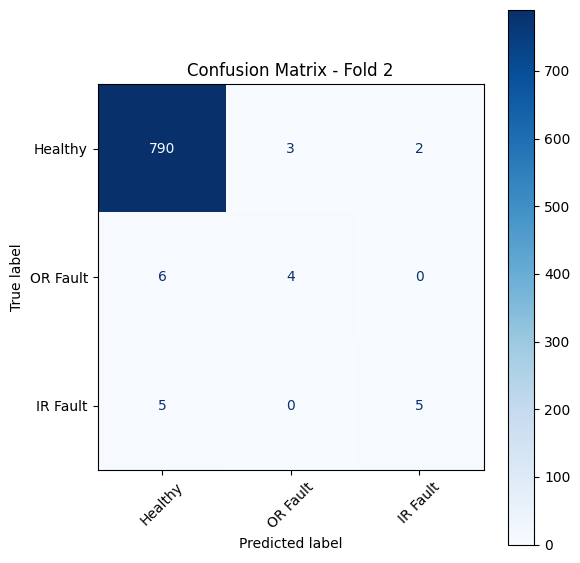

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 424ms/step - accuracy: 0.2441 - loss: 0.0238 - val_accuracy: 0.9785 - val_loss: 0.0120
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.4191 - loss: 0.0121
Epoch 9: val_accuracy did not improve from 0.97849
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 385ms/step - accuracy: 0.4196 - loss: 0.0121 - val_accuracy: 0.9386 - val_loss: 0.0108
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6432 - loss: 0.0076
Epoch 10: val_accuracy did not improve from 0.97849
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 392ms/step - accuracy: 0.6434 - loss: 0.0076 - val_accuracy: 0.8141 - val_loss: 0.0098
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6983 - loss: 0.0052
Epoch 11: val_accuracy did not improve from 0.97849
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 388ms/step - accuracy: 0.6988 - loss: 0.0052 - val_accuracy: 0.6068 - val_loss: 0.0162
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.7655 - loss: 0.0082
Epoch 12: val_accuracy

82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 492ms/step - accuracy: 0.9185 - loss: 0.0016 - val_accuracy: 0.9800 - val_loss: 0.0018
Epoch 50/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9478 - loss: 0.0010
Epoch 50: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 377ms/step - accuracy: 0.9476 - loss: 0.0010 - val_accuracy: 0.6682 - val_loss: 0.0200
Epoch 51/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8524 - loss: 0.0028
Epoch 51: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 393ms/step - accuracy: 0.8527 - loss: 0.0028 - val_accuracy: 0.9401 - val_loss: 0.0030
Epoch 52/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8778 - loss: 0.0021
Epoch 52: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 362ms/step - accuracy: 0.8783 - loss: 0.0021 - val_accuracy: 0.9631 - val_loss: 0.0020
Epoch 53/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9490 - loss: 9.6399e-04
Epoch 53: val_ac

82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 391ms/step - accuracy: 0.9659 - loss: 8.7922e-04 - val_accuracy: 0.9923 - val_loss: 0.0022
Epoch 55/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9657 - loss: 5.0694e-04
Epoch 55: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 402ms/step - accuracy: 0.9658 - loss: 5.0633e-04 - val_accuracy: 0.9508 - val_loss: 0.0036
Epoch 56/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9817 - loss: 3.8740e-04
Epoch 56: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 39s 476ms/step - accuracy: 0.9817 - loss: 3.8734e-04 - val_accuracy: 0.9923 - val_loss: 0.0015
Epoch 57/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9897 - loss: 3.5436e-04
Epoch 57: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 418ms/step - accuracy: 0.9896 - loss: 3.5511e-04 - val_accuracy: 0.9355 - val_loss: 0.0037
Epoch 58/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9637 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 413ms/step - accuracy: 0.9868 - loss: 2.1341e-04 - val_accuracy: 0.9939 - val_loss: 0.0023
Epoch 63/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9918 - loss: 1.5618e-04
Epoch 63: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 519ms/step - accuracy: 0.9919 - loss: 1.5607e-04 - val_accuracy: 0.9923 - val_loss: 0.0025
Epoch 64/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9957 - loss: 1.1153e-04
Epoch 64: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 412ms/step - accuracy: 0.9957 - loss: 1.1152e-04 - val_accuracy: 0.9877 - val_loss: 0.0011
Epoch 65/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9955 - loss: 1.2230e-04
Epoch 65: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 408ms/step - accuracy: 0.9955 - loss: 1.2203e-04 - val_accuracy: 0.9908 - val_loss: 0.0014
Epoch 66/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9973 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 425ms/step - accuracy: 0.9990 - loss: 5.7588e-05 - val_accuracy: 0.9954 - val_loss: 0.0020
Epoch 69/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9991 - loss: 5.2892e-05
Epoch 69: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 438ms/step - accuracy: 0.9991 - loss: 5.2883e-05 - val_accuracy: 0.9939 - val_loss: 0.0024
Epoch 70/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9921 - loss: 1.5449e-04
Epoch 70: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 423ms/step - accuracy: 0.9922 - loss: 1.5404e-04 - val_accuracy: 0.9785 - val_loss: 0.0016
Epoch 71/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9980 - loss: 9.6496e-05
Epoch 71: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 408ms/step - accuracy: 0.9980 - loss: 9.6232e-05 - val_accuracy: 0.9939 - val_loss: 0.0026
Epoch 72/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9976 - loss:

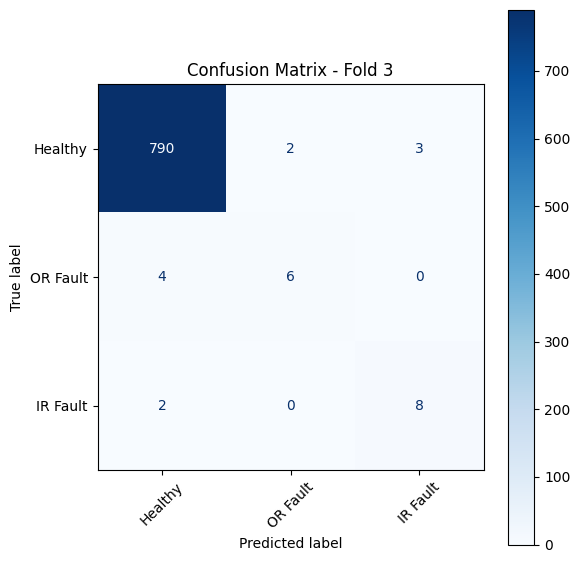

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 57s 693ms/step - accuracy: 0.9799 - loss: 6.0177e-04 - val_accuracy: 0.9862 - val_loss: 0.0024
Epoch 57/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9748 - loss: 4.8824e-04
Epoch 57: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 430ms/step - accuracy: 0.9748 - loss: 4.8830e-04 - val_accuracy: 0.9616 - val_loss: 0.0050
Epoch 58/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9811 - loss: 4.4781e-04
Epoch 58: val_accuracy improved from 0.98618 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 37s 453ms/step - accuracy: 0.9811 - loss: 4.4632e-04 - val_accuracy: 0.9877 - val_loss: 0.0018
Epoch 59/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9905 - loss: 3.6172e-04
Epoch 59: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 405ms/step - accuracy: 0.9905 - loss: 3.6286e-04 - val_accuracy: 0.9524 - val_loss: 0.0052
Epoch 60/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9823 - loss: 5.5670e-04
Epoch 60: val_accuracy improved from 0.98771 to 0.98925, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 412ms/step - accuracy: 0.9823 - loss: 5.5416e-04 - val_accuracy: 0.9892 - val_loss: 0.0037
Epoch 61/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9925 - loss: 4.9217e-04
Epoch 61: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 415ms/step - accuracy: 0.9924 - loss: 4.9211e-04 - val_accuracy: 0.9416 - val_loss: 0.0089
Epoch 62/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9846 - loss: 3.3590e-04
Epoch 62: val_accuracy improved from 0.98925 to 0.99232, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 521ms/step - accuracy: 0.9846 - loss: 3.3564e-04 - val_accuracy: 0.9923 - val_loss: 0.0058
Epoch 63/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9916 - loss: 3.6446e-04
Epoch 63: val_accuracy improved from 0.99232 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 497ms/step - accuracy: 0.9916 - loss: 3.6292e-04 - val_accuracy: 0.9939 - val_loss: 0.0058
Epoch 64/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.9767 - loss: 0.0011
Epoch 64: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 44s 542ms/step - accuracy: 0.9766 - loss: 0.0011 - val_accuracy: 0.4670 - val_loss: 0.0617
Epoch 65/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.5008 - loss: 0.1138
Epoch 65: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 395ms/step - accuracy: 0.4985 - loss: 0.1146 - val_accuracy: 0.0338 - val_loss: 0.0650
Epoch 66/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.0647 - loss: 0.1026
Epoch 66: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 428ms/step - accuracy: 0.0652 - loss: 0.1022 - val_accuracy: 0.0384 - val_loss: 0.0882
Epoch 67/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.1997 - loss: 0.0627
Epoch 67: val_ac

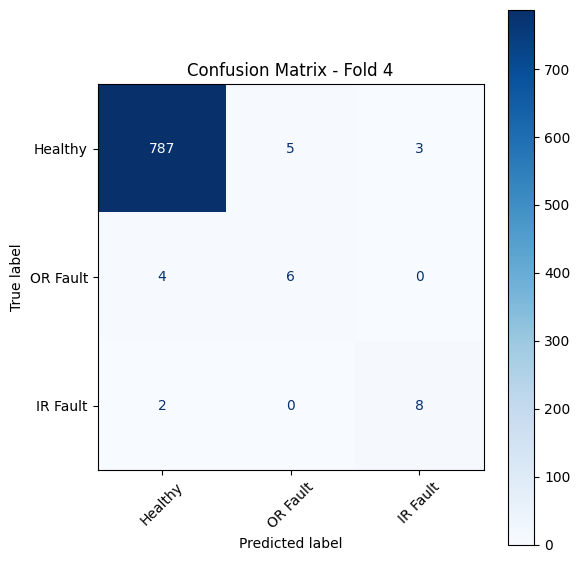

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 493ms/step - accuracy: 0.8704 - loss: 0.0036 - val_accuracy: 0.9831 - val_loss: 0.0115
Epoch 35/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8844 - loss: 0.0023
Epoch 35: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 425ms/step - accuracy: 0.8845 - loss: 0.0023 - val_accuracy: 0.9816 - val_loss: 0.0039
Epoch 36/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9359 - loss: 0.0014
Epoch 36: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 430ms/step - accuracy: 0.9359 - loss: 0.0014 - val_accuracy: 0.9739 - val_loss: 0.0037
Epoch 37/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9437 - loss: 0.0014
Epoch 37: val_accuracy did not improve from 0.98310
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 430ms/step - accuracy: 0.9435 - loss: 0.0014 - val_accuracy: 0.9493 - val_loss: 0.0040
Epoch 38/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9423 - loss: 0.0017
Epoch 38: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 411ms/step - accuracy: 0.9423 - loss: 0.0017 - val_accuracy: 0.9846 - val_loss: 0.0043
Epoch 39/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9511 - loss: 0.0017
Epoch 39: val_accuracy improved from 0.98464 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 412ms/step - accuracy: 0.9511 - loss: 0.0016 - val_accuracy: 0.9877 - val_loss: 0.0038
Epoch 40/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9714 - loss: 6.2809e-04
Epoch 40: val_accuracy improved from 0.98771 to 0.98925, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 412ms/step - accuracy: 0.9714 - loss: 6.2765e-04 - val_accuracy: 0.9892 - val_loss: 0.0053
Epoch 41/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9870 - loss: 5.2670e-04
Epoch 41: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 413ms/step - accuracy: 0.9869 - loss: 5.2748e-04 - val_accuracy: 0.9877 - val_loss: 0.0038
Epoch 42/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9852 - loss: 5.1799e-04
Epoch 42: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 402ms/step - accuracy: 0.9852 - loss: 5.1872e-04 - val_accuracy: 0.9370 - val_loss: 0.0049
Epoch 43/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9833 - loss: 4.0484e-04
Epoch 43: val_accuracy improved from 0.98925 to 0.99078, saving model to Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 444ms/step - accuracy: 0.9833 - loss: 4.0468e-04 - val_accuracy: 0.9908 - val_loss: 0.0035
Epoch 44/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9871 - loss: 4.3577e-04
Epoch 44: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 407ms/step - accuracy: 0.9870 - loss: 4.3772e-04 - val_accuracy: 0.9862 - val_loss: 0.0034
Epoch 45/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9856 - loss: 3.4076e-04
Epoch 45: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.9856 - loss: 3.4083e-04 - val_accuracy: 0.9908 - val_loss: 0.0071
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9921 - loss: 3.4713e-04
Epoch 46: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 416ms/step - accuracy: 0.9921 - loss: 3.4644e-04 - val_accuracy: 0.9908 - val_loss: 0.0044
Epoch 47/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9926 - loss:

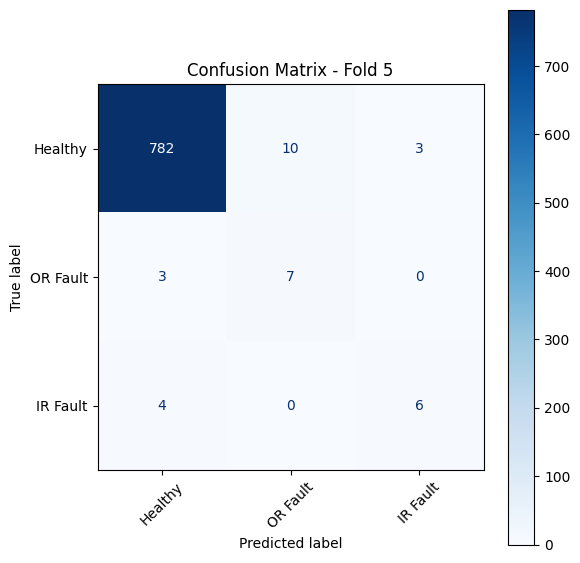

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha-2/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 29270.39 seconds (487.84 minutes)


In [11]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-Scalogram-FL-Alpha/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1,class_weight=class_weights)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [12]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 99.15%
Test Accuracy: 98.01%
Train Precision: 98.70%
Test Precision: 97.59%
Train Recall: 99.15%
Test Recall: 98.01%
Train F1: 98.91%
Test F1: 97.77%
Train Log Loss: 0.1028
Test Log Loss: 0.1276
Train Balanced Accuracy: 84.24%
Test Balanced Accuracy: 66.41%
Train Precision (Macro): 79.82%
Train Recall (Macro): 84.24%
Train F1 Score (Macro): 81.88%
Test Precision (Macro): 67.01%
Test Recall (Macro): 66.41%
Test F1 Score (Macro): 66.13%


102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step

 Classification Report - 2
              precision    recall  f1-score   support

     Healthy       1.00      0.99      1.00      3175
    OR Fault       0.84      0.95      0.89        40
    IR Fault       0.78      0.97      0.87        40

    accuracy                           0.99      3255
   macro avg       0.87      0.97      0.92      3255
weighted avg       0.99      0.99      0.99      3255



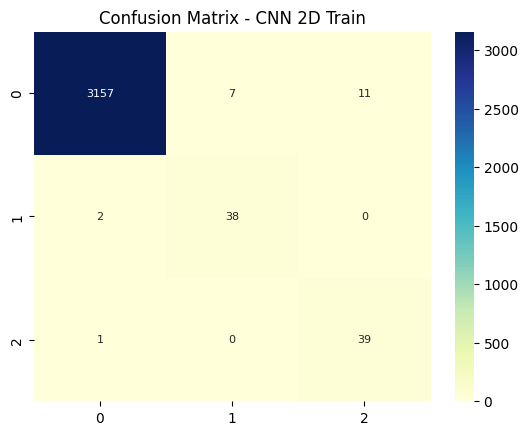

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step

 Classification Report - 2
              precision    recall  f1-score   support

     Healthy       0.99      0.98      0.99       795
    OR Fault       0.41      0.70      0.52        10
    IR Fault       0.67      0.60      0.63        10

    accuracy                           0.98       815
   macro avg       0.69      0.76      0.71       815
weighted avg       0.98      0.98      0.98       815



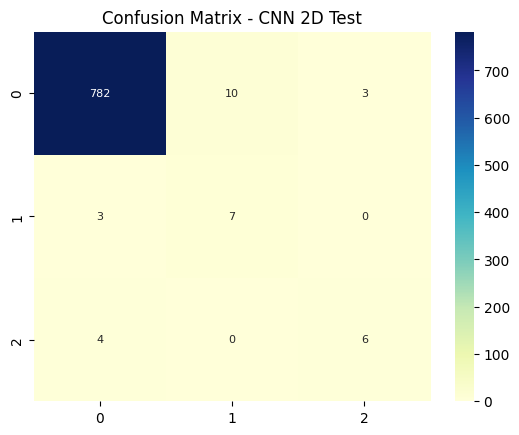

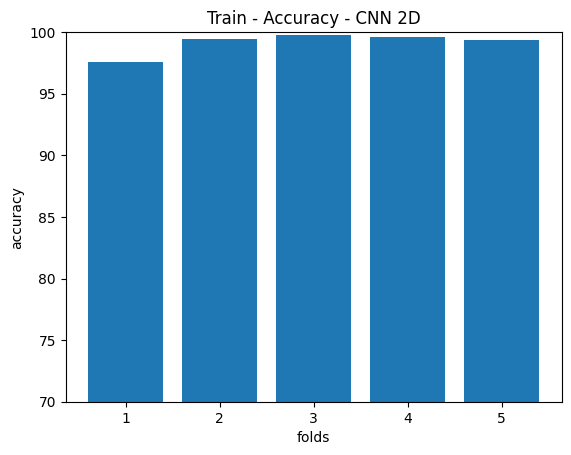

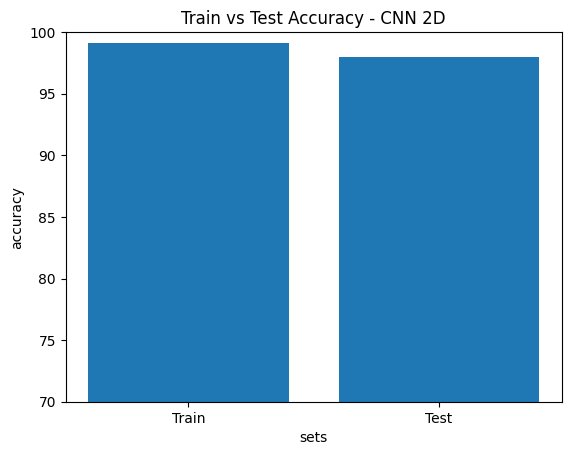

In [13]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    print(f"\n Classification Report - {label}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=2))
    return confusion_matrix(y_true, y_pred)

class_names = ['Healthy', 'OR Fault', 'IR Fault'] 

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()




In [14]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_2D) * 100,
    'Test Accuracy (%)': np.array(accuracy_2D_test) * 100,

    'Train Precision (%)': np.array(precision_2D) * 100,
    'Test Precision (%)': np.array(precision_2D_test) * 100,

    'Train Recall (%)': np.array(recall_2D) * 100,
    'Test Recall (%)': np.array(recall_2D_test) * 100,

    'Train F1-score (%)': np.array(f1_2D) * 100,
    'Test F1-score (%)': np.array(f1_2D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_2D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_2D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_2D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_2D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_2D_macro) * 100,
    'Test F1-score (%)': np.array(f1_2D_test_macro) * 100,

    'Train Log Loss': log_loss_2D,
    'Test Log Loss': log_loss_2D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_2D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_2D_test) * 100,
})

metrics_df.round(2)
# Sort by highest Test F1-score (%)
# sorted_df = metrics_df.sort_values(by='Test Balanced Accuracy (%)', ascending=False)
# sorted_df.round(2)

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Precision-Macro (%),Test Precision-Macro (%),Train Recall-Macro (%),Test Recall-Macro (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,97.54,97.55,95.14,95.15,97.54,97.55,32.92,32.92,32.51,32.52,33.33,33.33,0.26,0.26,33.33,33.33
1,2,99.45,98.04,99.48,97.78,99.45,98.04,92.72,68.29,90.74,75.73,94.87,63.12,0.04,0.07,94.87,63.12
2,3,99.78,98.65,99.80,98.62,99.78,98.65,97.11,80.72,96.09,82.32,98.28,79.79,0.05,0.08,98.28,79.79
3,4,99.60,98.28,99.62,98.37,99.60,98.28,94.72,77.48,92.30,75.51,97.40,79.66,0.04,0.08,97.40,79.66
4,5,99.35,97.55,99.45,98.00,99.35,97.55,91.92,71.25,87.45,68.99,97.31,76.12,0.12,0.15,97.31,76.12
